## Setup
Import libraries and `src` modules.

In [43]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier, LGBMRegressor

from src.preprocessing import load_data, split_data, fit_propensity, build_features
from src.learners import (
    fit_s_learner, predict_s_learner,
    fit_t_learner, predict_t_learner,
    fit_x_learner, predict_x_learner,
    fit_causal_forest, predict_causal_forest,
)
from src.evaluation import (
    build_eval_df, compute_qini,
    policy_simulation, policy_thresholds,
    causal_forest_segments, causal_forest_qini,
)
from src.visualization import (
    plot_cate_distribution, plot_cate_full_and_clipped,
    plot_learner_comparison, plot_qini_curves,
    plot_policy_simulation, plot_shap,
    plot_causal_forest_uncertainty,
)

## Data Loading
Load the Criteo uplift v2.1 dataset.

In [44]:
df = load_data('/Users/amansingh/Desktop/CI project/data/criteo-uplift-v2.1.csv')

## Exploratory Data Analysis
Inspect dataset shape, sample rows, and summary statistics.

In [45]:
df.shape

(13979592, 16)

In [46]:
df.head(5)

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


In [47]:
df.describe()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
count,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07
mean,1.962030e+01,1.006998e+01,8.446582e+00,4.178923e+00,1.033884e+01,4.028513e+00,-4.155356e+00,5.101765e+00,3.933581e+00,1.602764e+01,5.333396e+00,-1.709672e-01,8.500001e-01,2.916680e-03,4.699200e-02,3.063122e-02
std,5.377464e+00,1.047557e-01,2.993161e-01,1.336645e+00,3.433081e-01,4.310974e-01,4.577914e+00,1.205248e+00,5.665958e-02,7.018975e+00,1.682288e-01,2.283277e-02,3.570713e-01,5.392748e-02,2.116217e-01,1.723164e-01
min,1.261636e+01,1.005965e+01,8.214383e+00,-8.398387e+00,1.028053e+01,-9.011892e+00,-3.142978e+01,4.833815e+00,3.635107e+00,1.319006e+01,5.300375e+00,-1.383941e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.261636e+01,1.005965e+01,8.214383e+00,4.679882e+00,1.028053e+01,4.115453e+00,-6.699321e+00,4.833815e+00,3.910792e+00,1.319006e+01,5.300375e+00,-1.686792e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.192341e+01,1.005965e+01,8.214383e+00,4.679882e+00,1.028053e+01,4.115453e+00,-2.411115e+00,4.833815e+00,3.971858e+00,1.319006e+01,5.300375e+00,-1.686792e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.443646e+01,1.005965e+01,8.723335e+00,4.679882e+00,1.028053e+01,4.115453e+00,2.944427e-01,4.833815e+00,3.971858e+00,1.319006e+01,5.300375e+00,-1.686792e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2.674526e+01,1.634419e+01,9.051962e+00,4.679882e+00,2.112351e+01,4.115453e+00,2.944427e-01,1.199840e+01,3.971858e+00,7.529502e+01,6.473917e+00,-1.686792e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


### Treatment & Outcome Rates
Check class balance across treatment, conversion, and visit.

In [48]:
# treatment / outcome rates
print(df["treatment"].value_counts(normalize=True))
print(df["conversion"].value_counts(normalize=True))
print(df["visit"].value_counts(normalize=True))

treatment
1    0.85
0    0.15
Name: proportion, dtype: float64
conversion
0    0.997083
1    0.002917
Name: proportion, dtype: float64
visit
0    0.953008
1    0.046992
Name: proportion, dtype: float64


### Outcome Rates by Group
Compare conversion and visit rates between treatment and control.

In [49]:
# conversion rate by treatment group
print(df.groupby("treatment")["conversion"].mean())
print(df.groupby("treatment")["visit"].mean())

treatment
0    0.001938
1    0.003089
Name: conversion, dtype: float64
treatment
0    0.038201
1    0.048543
Name: visit, dtype: float64


In [50]:
df.groupby("treatment")["conversion"].mean()

treatment
0    0.001938
1    0.003089
Name: conversion, dtype: float64

In [51]:
df.groupby("treatment")[["conversion", "visit"]].mean()

,conversion,visit
treatment,,
0,0.001938,0.038201
1,0.003089,0.048543


### Feature Statistics
Descriptive statistics and cardinality for the 12 covariates.

In [52]:
df[[f"f{i}" for i in range(12)]].describe()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11
count,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07
mean,1.962030e+01,1.006998e+01,8.446582e+00,4.178923e+00,1.033884e+01,4.028513e+00,-4.155356e+00,5.101765e+00,3.933581e+00,1.602764e+01,5.333396e+00,-1.709672e-01
std,5.377464e+00,1.047557e-01,2.993161e-01,1.336645e+00,3.433081e-01,4.310974e-01,4.577914e+00,1.205248e+00,5.665958e-02,7.018975e+00,1.682288e-01,2.283277e-02
min,1.261636e+01,1.005965e+01,8.214383e+00,-8.398387e+00,1.028053e+01,-9.011892e+00,-3.142978e+01,4.833815e+00,3.635107e+00,1.319006e+01,5.300375e+00,-1.383941e+00
25%,1.261636e+01,1.005965e+01,8.214383e+00,4.679882e+00,1.028053e+01,4.115453e+00,-6.699321e+00,4.833815e+00,3.910792e+00,1.319006e+01,5.300375e+00,-1.686792e-01
50%,2.192341e+01,1.005965e+01,8.214383e+00,4.679882e+00,1.028053e+01,4.115453e+00,-2.411115e+00,4.833815e+00,3.971858e+00,1.319006e+01,5.300375e+00,-1.686792e-01
75%,2.443646e+01,1.005965e+01,8.723335e+00,4.679882e+00,1.028053e+01,4.115453e+00,2.944427e-01,4.833815e+00,3.971858e+00,1.319006e+01,5.300375e+00,-1.686792e-01
max,2.674526e+01,1.634419e+01,9.051962e+00,4.679882e+00,2.112351e+01,4.115453e+00,2.944427e-01,1.199840e+01,3.971858e+00,7.529502e+01,6.473917e+00,-1.686792e-01


In [53]:
df[[f"f{i}" for i in range(12)]].nunique()

f0     2181959
f1          60
f2     2051900
f3         552
f4         260
f5         132
f6        1645
f7      622143
f8        3743
f9        1594
f10     517372
f11        136
dtype: int64

In [54]:
df.groupby("treatment")[[f"f{i}" for i in range(12)]].mean()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11
treatment,,,,,,,,,,,,
0,19.651705,10.067935,8.448173,4.232821,10.336526,4.039339,-3.999880,5.080284,3.934652,15.886253,5.331898,-0.170868
1,19.614755,10.070337,8.446302,4.169412,10.339245,4.026602,-4.182792,5.105555,3.933392,16.052589,5.333660,-0.170985


## Preprocessing
Train-test split (80/20, `random_state=42`).

In [55]:
X_train, X_test, T_train, T_test, y_train, y_test = split_data(df)

### Propensity Model
Fit logistic regression to predict treatment assignment.

In [56]:
lr = fit_propensity(X_train, T_train)
auc = roc_auc_score(T_test, lr.predict_proba(X_test)[:, 1])
print(f"Propensity model AUC: {auc:.4f}")

Propensity model AUC: 0.5093


Propensity model AUC of 0.51 confirms near-random treatment assignment. Covariate balance across treatment and control groups is strong (mean differences < 0.2 across all features), supporting the validity of CATE estimation without heavy propensity weighting.

### Feature Augmentation
Standardize covariates and append propensity score as a 13th feature.

In [57]:
X_train_final, X_test_final = build_features(X_train, X_test, lr)

## Meta-Learners — CATE Estimation
### S-Learner (Classifier — Experiment)
Initial run with `LGBMClassifier`; superseded by the regressor below.

In [58]:
s_learner = fit_s_learner(
    X_train_final, T_train, y_train,
    LGBMClassifier(n_estimators=200, random_state=42),
)
cate_s = predict_s_learner(s_learner, X_test_final)
print(f"CATE mean: {cate_s.mean():.4f}")
print(f"CATE std: {cate_s.std():.4f}")
print(f"CATE min: {cate_s.min():.4f}")
print(f"CATE max: {cate_s.max():.4f}")

[LightGBM] [Info] Number of positive: 525411, number of negative: 10658262
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.736235 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1826
[LightGBM] [Info] Number of data points in the train set: 11183673, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.046980 -> initscore=-3.009910
[LightGBM] [Info] Start training from score -3.009910


/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CATE mean: 0.0065
CATE std: 0.0813
CATE min: -1.0000
CATE max: 1.0000


### S-Learner (Regressor)
Final S-Learner using `LGBMRegressor`.

In [59]:
s_learner = fit_s_learner(
    X_train_final, T_train, y_train,
    LGBMRegressor(
        n_estimators=200,
        min_child_samples=5,
        reg_lambda=0,
        reg_alpha=0,
        random_state=42,
    ),
)
cate_s = predict_s_learner(s_learner, X_test_final)
print(f"CATE mean: {cate_s.mean():.4f}")
print(f"CATE std: {cate_s.std():.4f}")
print(f"CATE min: {cate_s.min():.4f}")
print(f"CATE max: {cate_s.max():.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.303846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1826
[LightGBM] [Info] Number of data points in the train set: 11183673, number of used features: 14
[LightGBM] [Info] Start training from score 0.046980


/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CATE mean: 0.0070
CATE std: 0.0223
CATE min: -0.0536
CATE max: 0.3251


### S-Learner CATE Distribution

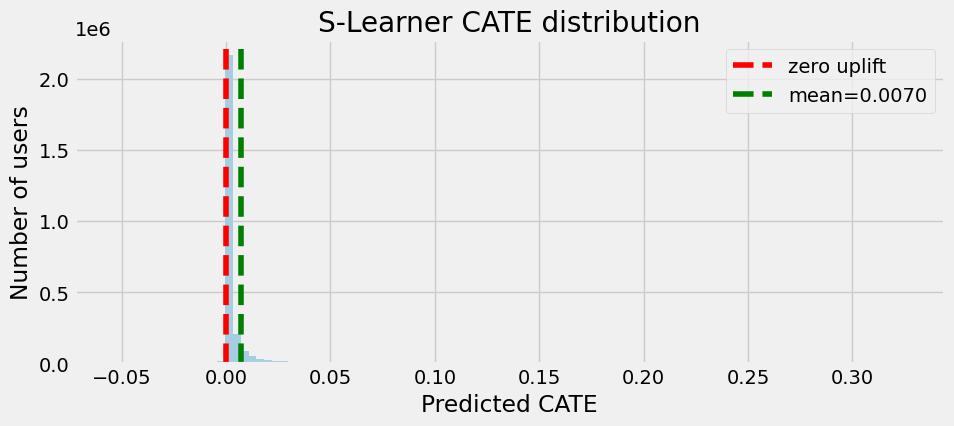

In [60]:
plot_cate_distribution(cate_s, 'S-Learner')

### T-Learner
Fit separate outcome models for treated and control groups.

In [61]:
t_learner = fit_t_learner(
    X_train_final, T_train, y_train,
    LGBMRegressor(n_estimators=200, random_state=42),
)
cate_t = predict_t_learner(t_learner, X_test_final, T_test)
print(f"CATE mean: {cate_t.mean():.4f}")
print(f"CATE std: {cate_t.std():.4f}")
print(f"CATE min: {cate_t.min():.4f}")
print(f"CATE max: {cate_t.max():.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031172 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1812
[LightGBM] [Info] Number of data points in the train set: 1678590, number of used features: 13
[LightGBM] [Info] Start training from score 0.038252
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.202318 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1825
[LightGBM] [Info] Number of data points in the train set: 9505083, number of used features: 13
[LightGBM] [Info] Start training from score 0.048522


/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CATE mean: 0.0074
CATE std: 0.0267
CATE min: -0.3686
CATE max: 0.6310


### T-Learner CATE Distribution

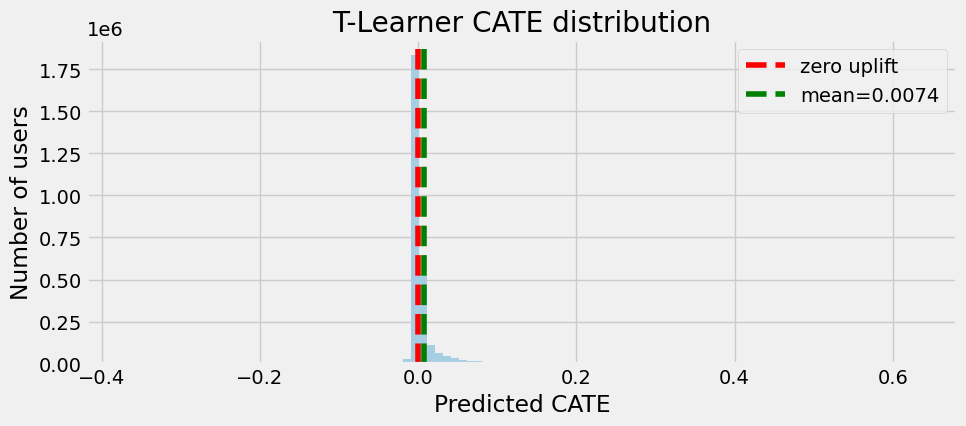

In [62]:
plot_cate_distribution(cate_t, 'T-Learner')

### T-Learner CATE — Full Range vs Clipped
Clip to 1st–99th percentile to suppress outlier influence on the histogram.

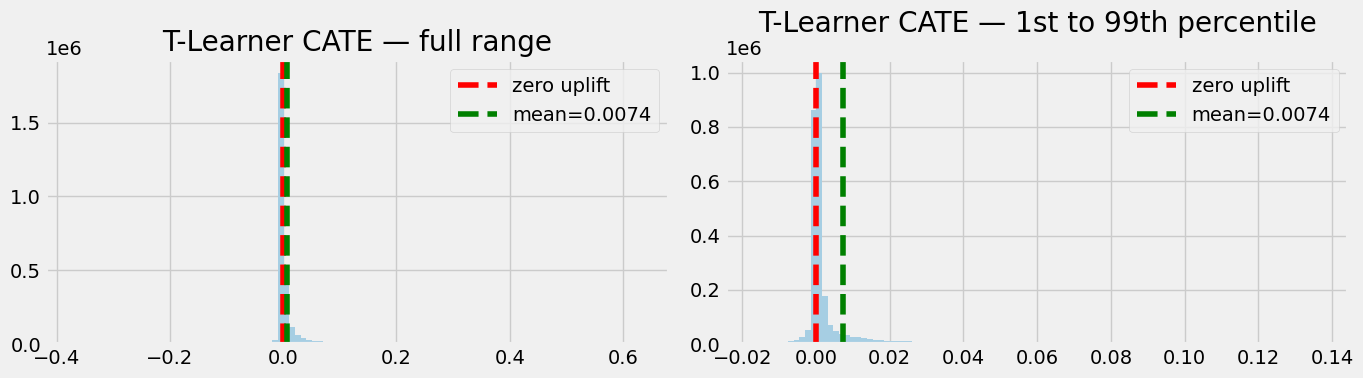

In [63]:
plot_cate_full_and_clipped(cate_t, 'T-Learner')

### X-Learner
Fit X-Learner combining imputed treatment effects from both groups.

In [64]:
x_learner = fit_x_learner(
    X_train_final, T_train, y_train,
    LGBMRegressor(n_estimators=200, random_state=42),
)
cate_x = predict_x_learner(x_learner, X_test_final, T_test)
print(f"CATE mean: {cate_x.mean():.4f}")
print(f"CATE std: {cate_x.std():.4f}")
print(f"CATE min: {cate_x.min():.4f}")
print(f"CATE max: {cate_x.max():.4f}")

/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039907 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1812
[LightGBM] [Info] Number of data points in the train set: 1678590, number of used features: 13
[LightGBM] [Info] Start training from score 0.038252
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.196787 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1825
[LightGBM] [Info] Number of data points in the train set: 9505083, number of used features: 13
[LightGBM] [Info] Start training from score 0.048522


/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1812
[LightGBM] [Info] Number of data points in the train set: 1678590, number of used features: 13
[LightGBM] [Info] Start training from score 0.006147
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.181470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1825
[LightGBM] [Info] Number of data points in the train set: 9505083, number of used features: 13
[LightGBM] [Info] Start training from score 0.007604


/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CATE mean: 0.0074
CATE std: 0.0248
CATE min: -0.2287
CATE max: 0.6856


### Learner Comparison
Side-by-side clipped CATE distributions for all three meta-learners.

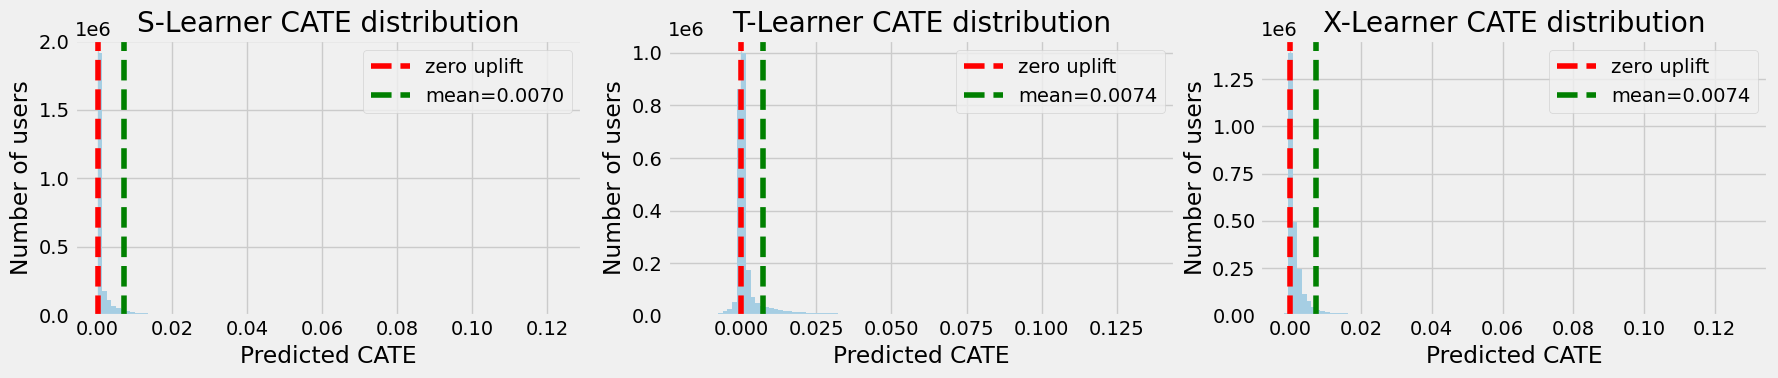

In [76]:
plot_learner_comparison(cate_s, cate_t, cate_x)

## Evaluation
Build evaluation frame, compute Qini scores, and plot cumulative gain curves.

S-Learner    0.375937
T-Learner    0.350338
X-Learner    0.361476
Random       0.007221
dtype: float64


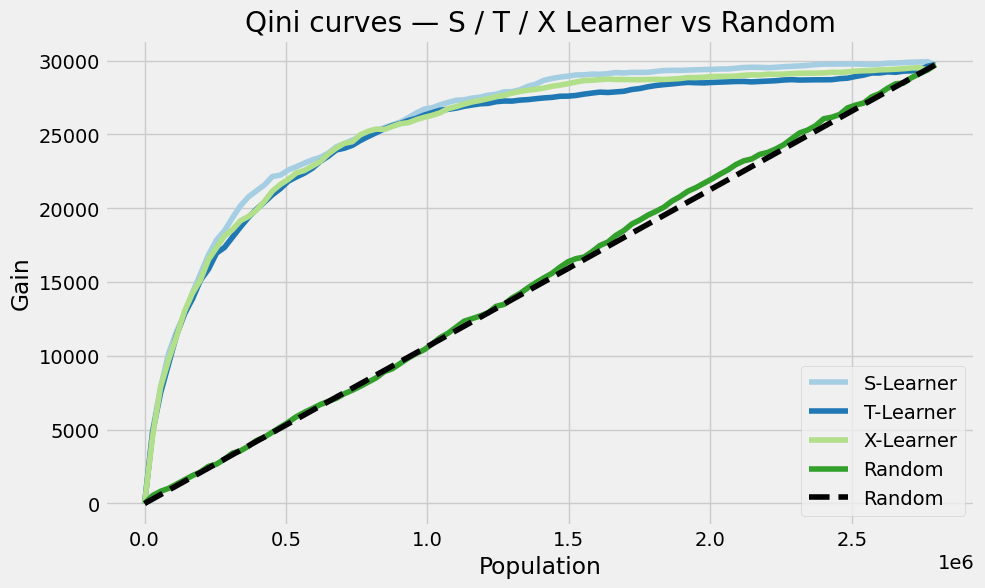

In [77]:
df_eval = build_eval_df(y_test, T_test, cate_s, cate_t, cate_x)
scores = compute_qini(df_eval)
print(scores)
plot_qini_curves(df_eval)

### Policy Simulation
Model incremental conversions captured as a function of targeting budget.

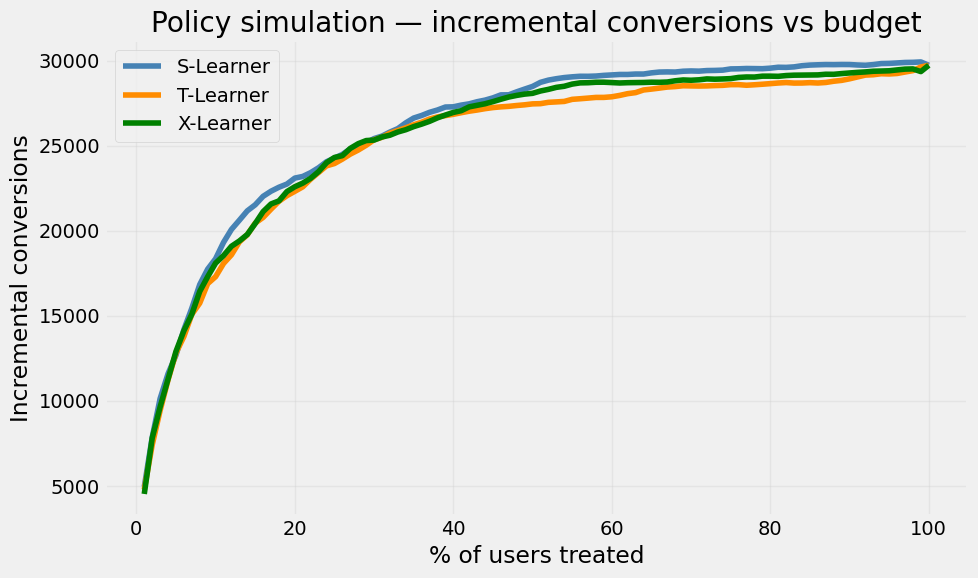

In [78]:
plot_policy_simulation(
    [cate_s, cate_t, cate_x],
    ['S-Learner', 'T-Learner', 'X-Learner'],
    ['steelblue', 'darkorange', 'green'],
    y_test, T_test,
)

### Policy Thresholds
Lift captured at the 20%, 30%, and 50% targeting thresholds.

In [79]:
for cate, name in zip([cate_s, cate_t, cate_x], ['S-Learner', 'T-Learner', 'X-Learner']):
    policy_thresholds(cate, name, y_test, T_test)

S-Learner — top 20% users captures 77.7% of total incremental conversions
S-Learner — top 30% users captures 85.5% of total incremental conversions
S-Learner — top 50% users captures 95.8% of total incremental conversions

T-Learner — top 20% users captures 75.1% of total incremental conversions
T-Learner — top 30% users captures 85.3% of total incremental conversions
T-Learner — top 50% users captures 92.4% of total incremental conversions

X-Learner — top 20% users captures 76.0% of total incremental conversions
X-Learner — top 30% users captures 85.2% of total incremental conversions
X-Learner — top 50% users captures 94.5% of total incremental conversions



### T-Learner Internals
Inspect model attributes for SHAP extraction.

In [80]:
print(dir(t_learner))

['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_classes', '_format_p', '_set_propensity_models', 'ate_alpha', 'bootstrap', 'control_name', 'estimate_ate', 'fit', 'fit_predict', 'get_importance', 'get_shap_values', 'model_c', 'model_t', 'models_c', 'models_t', 'plot_importance', 'plot_shap_dependence', 'plot_shap_values', 'predict', 't_groups']


In [81]:
print(t_learner.models_c.keys())
print(t_learner.models_t.keys())

dict_keys([np.int64(1)])
dict_keys([np.int64(1)])


## SHAP Feature Importance
Differential SHAP (treat − control) to explain CATE heterogeneity via the T-Learner.

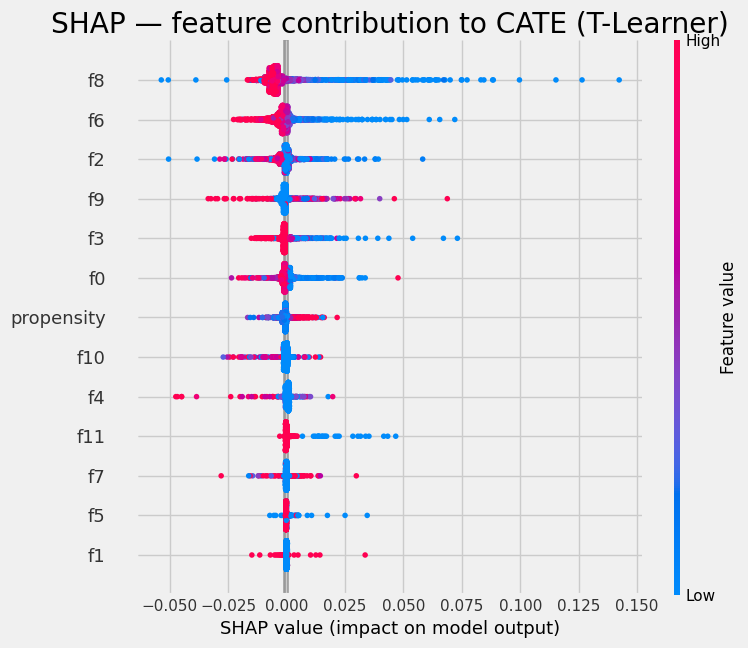

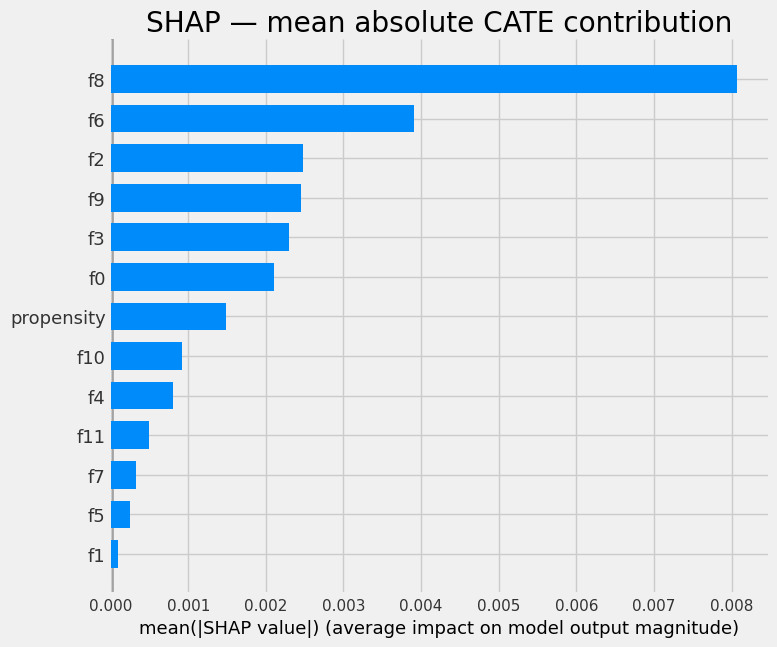

In [82]:
plot_shap(t_learner, X_test_final)

In [72]:
# superseded by Cell 31 (sampled) — skipped to avoid full-dataset CausalForest fit

## Causal Forest
Fit on a 10% subsample for speed; predict CATEs with 95% confidence intervals.

In [83]:
cf = fit_causal_forest(X_train_final, T_train, y_train, sample_frac=0.1)
cate_cf, lb, ub, test_idx = predict_causal_forest(cf, X_test_final, sample_frac=0.1)

print(f"CATE mean: {cate_cf.mean():.4f}")
print(f"CATE std: {cate_cf.std():.4f}")
print(f"CATE min: {cate_cf.min():.4f}")
print(f"CATE max: {cate_cf.max():.4f}")
print()

causal_forest_segments(cate_cf, lb, ub)

CATE mean: 0.0073
CATE std: 0.0381
CATE min: -0.5206
CATE max: 0.4252

Confident persuadables: 5103 (1.8%)
Confident sleeping dogs: 223 (0.1%)
Uncertain: 274265 (98.1%)


### Causal Forest Qini
Evaluate Causal Forest ranking performance.

In [84]:
scores_cf = causal_forest_qini(df_eval, test_idx, cate_cf)
print(scores_cf)

S-Learner        0.406401
T-Learner        0.344702
X-Learner        0.378335
Random           0.056380
Causal Forest    0.293513
dtype: float64


### Causal Forest Uncertainty
CI width distribution and CATE estimate vs uncertainty scatter.

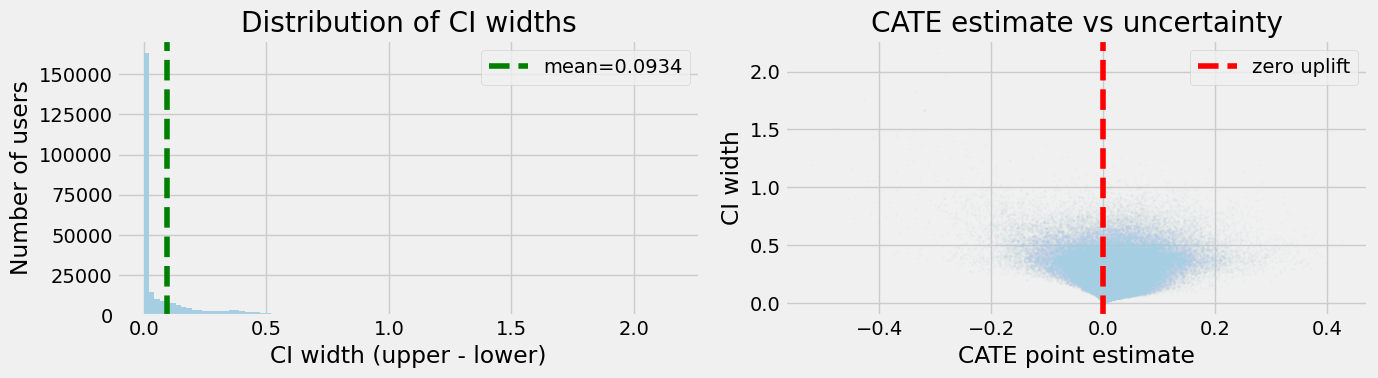

In [85]:
plot_causal_forest_uncertainty(cate_cf, lb, ub)

In [86]:
!jupyter nbconvert --to html modeling.ipynb

[NbConvertApp] Converting notebook modeling.ipynb to html
/Users/amansingh/Desktop/CI project/.venv/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] Writing 337906 bytes to modeling.html
